In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from ion_simulbox import Ion
from ion_simulbox.laser import Laser, Polarization
from ion_simulbox.experiment import Experiment
from ion_simulbox.units import Units, Constants
from ion_simulbox.utils import get_resonant_frequency

In [3]:
ion = Ion("Ba", 138)

In [4]:
ion.apply_magnetic_field(0 * Units.T)

In [54]:
laser_493 = Laser(
    "493 nm",
    get_resonant_frequency(ion.energy_levels[0], ion.energy_levels[1]),
    2550, 
    10 * Units.kHz, 
    Polarization(-np.array([0, 0, 1]), 1 / np.sqrt(2), 1j / np.sqrt(2))
)

In [55]:
laser_650 = Laser(
    "650 nm",
    get_resonant_frequency(ion.energy_levels[1], ion.energy_levels[3]),
    250, 
    10 * Units.kHz, 
    Polarization(np.array([0, 1, 1])/np.sqrt(2), 1 / np.sqrt(2), -1j / np.sqrt(2))
)

In [90]:
experiment = Experiment(ion, 1e-5 * Units.T)

In [91]:
experiment.add_levels([ion.energy_levels[0], ion.energy_levels[1], ion.energy_levels[3]])

In [92]:
experiment.add_laser(laser_493)
experiment.add_laser(laser_650)

In [93]:
experiment.compile()

Quadrupole transition not supported yet


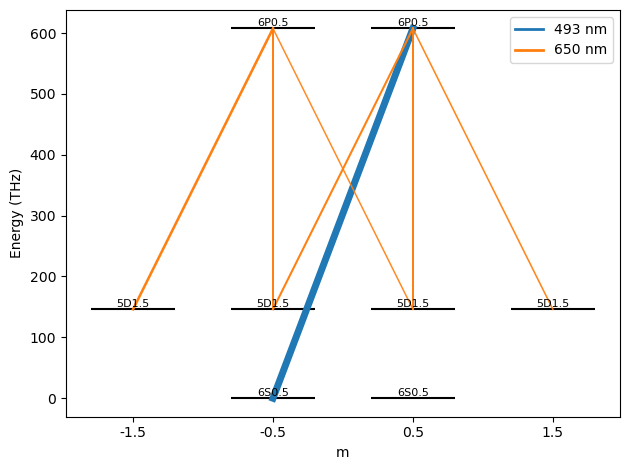

In [94]:
experiment.plot_transitions()

In [103]:
import qutip

In [104]:
kets = {}
for level in experiment.levels:
    for zeeman_level in level.zeeman_levels:
        kets[zeeman_level] = None
n_levels = len(kets)
for i, level in enumerate(kets.keys()):
    kets[level] = qutip.basis(n_levels, i)

In [105]:
kets

{FineStructureZeemanLevel(energy=-1.3996244925632676e-07 THz, n=6, I=0, L=0, J=0.5, m_J=-0.5): Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qobj data =
 [[1.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]],
 FineStructureZeemanLevel(energy=1.3996244925632676e-07 THz, n=6, I=0, L=0, J=0.5, m_J=0.5): Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.]
  [1.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]],
 FineStructureZeemanLevel(energy=607.4262999533458 THz, n=6, I=0, L=1, J=0.5, m_J=-0.5): Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.]
  [0.]
  [1.]
  [0.]
  [0.]
  [0.]
  [0.]
  [0.]],
 FineStructureZeemanLevel(energy=607.4263000466542 THz, n=6, I=0, L=1, J=0.5, m_J=0.5): Quantum object: dims=[[8], [1]], shape=(8, 1), type='ket', dtype=Dense
 Qobj data =
 [[0.]
  [0.]
  [0.]
  [1.]
  [0.]
  [0.]
  [0.]
  [0.]],
 FineStructureZeemanLevel(energy=146.11439983204505 THz, n=5, I=0, 

In [99]:
experiment.levels[0].zeeman_levels

[FineStructureZeemanLevel(energy=-1.3996244925632676e-07 THz, n=6, I=0, L=0, J=0.5, m_J=-0.5),
 FineStructureZeemanLevel(energy=1.3996244925632676e-07 THz, n=6, I=0, L=0, J=0.5, m_J=0.5)]

In [96]:
experiment.transitions[0].lower_level

FineStructureZeemanLevel(energy=-1.3996244925632676e-07 THz, n=6, I=0, L=0, J=0.5, m_J=-0.5)